# Automatic Game Balancing with Top Trumps

Install required packages:

In [ ]:
%pip install numpy pymoo

In [22]:
palette = {
    'navy': '#1e3a5f',           # Deep navy blue
    'dark_blue': '#2c5f8d',      # Medium dark blue
    'blue': '#4a90c8',           # Lighter blue
    'coral': '#ff6b4a',          # Vibrant coral
    'orange': '#fbb13c',         # Bright yellow-orange (was #ff8c42)
    'green': '#2ecc40',          # Bright green for contrast
    'gray': '#5a6c7d'            # Neutral gray
}

# Create lists for easy matplotlib usage
main_colors = [palette['navy'], palette['dark_blue'], palette['blue'], 
               palette['coral'], palette['orange'], palette['green'], palette['gray']]

blue_gradient = [palette['navy'], palette['dark_blue'], palette['blue']]

## Top Trumps Implementation

In [3]:
import random
import numpy as np

class TopTrumpsSimulation:
    """TopTrumpsSimulation implements the basic TopTrumps game engine and agent-based simulation."""

    def __init__(self, num_cards=52, num_categories=6):
        self.K = num_cards  # Number of cards
        self.L = num_categories  # Number of categories

        self.set_random_deck()

    def _normalize_deck(self, deck):
        """Normalizes the deck such that each property is in the range [0,1]. This is required for the p0 agent."""
        min_values = [0] * self.L
        max_values = [0] * self.L

        for cat in range(self.L):
            all_values = [card[cat] for card in deck]
            min_values[cat] = min(all_values)
            max_values[cat] = max(all_values)

        normalized_deck = []

        for card in deck:
            normalized_card = [0] * self.L
            for cat in range(self.L):
                normalized_card[cat] = (card[cat] - min_values[cat]) / (max_values[cat] - min_values[cat])
            normalized_deck.append(normalized_card)

        return normalized_deck

    def set_deck(self, deck_list):
        """Creates a deck from deck_list of length K*L."""

        assert len(deck_list) == self.K * self.L

        deck = np.array_split(deck_list, self.K)

        self.deck = deck
        self._normalized_deck = self._normalize_deck(deck)

    def set_random_deck(self, value_range = (1, 10)):
        """Generates a random deck with values in value_range."""
        deck_list = np.random.uniform(value_range[0], value_range[1], self.K * self.L)
        self.set_deck(deck_list)

    def get_p0_choice(self, card):
        """p0 assumes uniform distribution between max and min values per property and then picks the best value on current card."""
        return card.index(max(card))

    def get_p4_choice(self, card, remaining_cards):
        """p4 calculates exact win probability based on remaining cards."""
        best_prob = -1
        best_cat = 0

        for cat_idx in range(self.L):
            my_val = card[cat_idx]
            # Count how many cards in the potential card pool have a lower value
            wins = sum(1 for opp_card in remaining_cards if my_val > opp_card[cat_idx])
            prob = wins / len(remaining_cards)

            if prob > best_prob:
                best_prob = prob
                best_cat = cat_idx
        # print(f"Best prob: {best_prob:.2f}, cat: {best_cat}")
        return best_cat

    def simulate_game(self):
        # Shuffle and distribute cards
        temp_deck = list(self._normalized_deck)
        random.shuffle(temp_deck)

        # p4 vs p0 setup
        p4_hand = temp_deck[:self.K//2]
        p0_hand = temp_deck[self.K//2:]

        # Track unplayed cards remaining in the 'unplayed' pool for p4's knowledge 
        all_unplayed = list(temp_deck) 

        p4_tricks = 0
        current_turn = random.choice(['p4', 'p0']) # Random starting player
        trick_changes = 0

        # Game ends after all cards played once
        for i in range(self.K // 2):
            card_p4 = p4_hand[i]
            card_p0 = p0_hand[i]

            # Category Selection
            if current_turn == 'p4':
                category = self.get_p4_choice(card_p4, all_unplayed)
            else:
                category = self.get_p0_choice(card_p0)

            # Determine Round Winner
            val_p4 = card_p4[category]
            val_p0 = card_p0[category]

            # Remove current p0, p4 card from p4's tracking memory
            all_unplayed.remove(card_p0)
            all_unplayed.remove(card_p4)

            if val_p4 > val_p0:
                # print("P4 wins!")
                p4_tricks += 1
                if current_turn == 'p0':
                    current_turn = 'p4'
                    trick_changes += 1
            elif val_p0 > val_p4:
                # print("P0 wins!")
                if current_turn == 'p4':
                    current_turn = 'p0'
                    trick_changes += 1
            # In case of draw, current player keeps the lead

        return {
            "p4_tricks": p4_tricks,
            "trick_changes": trick_changes,
            "p4_won": p4_tricks > (self.K / 4) # p4 wins if they got more than half the tricks
        }

Test implementation on a random deck:

In [4]:
# Impact of number of repetitions on simulation results
# Test with the SAME deck and different repetition counts

num_cards = 22
num_categories = 4
repetitions_list = [100,200,400,800,1600]
seeds = [i for i in range(100)]

# Set seed and create ONE deck that will be used for all tests
np.random.seed(1)
random.seed(1)

sim = TopTrumpsSimulation(num_cards=num_cards, num_categories=num_categories)
deck_values = np.random.uniform(0, 10, num_cards * num_categories)
sim.set_deck(deck_values)

results_storage = []

for num_repetitions in repetitions_list:
    print(f"\n{'='*60}")
    print(f"Testing with {num_repetitions} repetitions")
    print(f"{'='*60}\n")
    
    for seed in seeds:
        # Only set the random seed for the game simulation, not the deck generation
        np.random.seed(seed)
        random.seed(seed)
        
        # Use the same deck for all repetition counts
        #sim.set_deck(deck_values)
        results = [sim.simulate_game() for _ in range(num_repetitions)]
        
        avg_p4_win_rate = sum(1 for r in results if r['p4_won']) / num_repetitions
        avg_tricks = sum(r['p4_tricks'] for r in results) / num_repetitions
        avg_trick_changes = sum(r['trick_changes'] for r in results) / num_repetitions
        
        # Store results
        results_storage.append({
            'repetitions': num_repetitions,
            'seed': seed,
            'p4_win_rate': avg_p4_win_rate,
            'avg_tricks': avg_tricks,
            'avg_trick_changes': avg_trick_changes
        })
        
        print(f"Seed {seed} - Results over {num_repetitions} runs:")
        print(f"  p4 Win Rate: {avg_p4_win_rate:.2%}")
        print(f"  Average p4 Tricks: {avg_tricks:.2f}")
        print(f"  Average Trick Changes: {avg_trick_changes:.2f}")
        print()

print("\n" + "="*60)
print("Summary of all results:")
print("="*60)
for num_rep in repetitions_list:
    print(f"\nRepetitions: {num_rep}")
    for res in results_storage:
        if res['repetitions'] == num_rep:
            print(f"  Seed {res['seed']}: Win Rate={res['p4_win_rate']:.2%}, Tricks={res['avg_tricks']:.2f}, Changes={res['avg_trick_changes']:.2f}")


Testing with 100 repetitions

Seed 0 - Results over 100 runs:
  p4 Win Rate: 56.00%
  Average p4 Tricks: 6.03
  Average Trick Changes: 2.15

Seed 1 - Results over 100 runs:
  p4 Win Rate: 54.00%
  Average p4 Tricks: 5.57
  Average Trick Changes: 2.53

Seed 2 - Results over 100 runs:
  p4 Win Rate: 56.00%
  Average p4 Tricks: 5.97
  Average Trick Changes: 2.49

Seed 3 - Results over 100 runs:
  p4 Win Rate: 55.00%
  Average p4 Tricks: 5.97
  Average Trick Changes: 2.30

Seed 4 - Results over 100 runs:
  p4 Win Rate: 54.00%
  Average p4 Tricks: 5.82
  Average Trick Changes: 2.43

Seed 5 - Results over 100 runs:
  p4 Win Rate: 56.00%
  Average p4 Tricks: 5.71
  Average Trick Changes: 2.49

Seed 6 - Results over 100 runs:
  p4 Win Rate: 62.00%
  Average p4 Tricks: 6.28
  Average Trick Changes: 2.26

Seed 7 - Results over 100 runs:
  p4 Win Rate: 52.00%
  Average p4 Tricks: 5.75
  Average Trick Changes: 2.19

Seed 8 - Results over 100 runs:
  p4 Win Rate: 47.00%
  Average p4 Tricks: 5.76
 


CONVERGENCE ANALYSIS: How variance decreases with increasing R

R = 100:
[0.56, 0.54, 0.56, 0.55, 0.54, 0.56, 0.62, 0.52, 0.47, 0.49, 0.54, 0.52, 0.53, 0.64, 0.56, 0.63, 0.59, 0.51, 0.52, 0.58, 0.64, 0.59, 0.55, 0.6, 0.63, 0.57, 0.58, 0.52, 0.56, 0.57, 0.55, 0.52, 0.56, 0.5, 0.53, 0.56, 0.57, 0.57, 0.58, 0.56, 0.46, 0.52, 0.47, 0.59, 0.54, 0.47, 0.51, 0.51, 0.53, 0.54, 0.53, 0.59, 0.57, 0.62, 0.5, 0.6, 0.59, 0.48, 0.56, 0.47, 0.46, 0.51, 0.57, 0.64, 0.54, 0.46, 0.52, 0.55, 0.52, 0.47, 0.55, 0.44, 0.59, 0.54, 0.52, 0.52, 0.55, 0.57, 0.58, 0.45, 0.49, 0.52, 0.63, 0.52, 0.54, 0.59, 0.53, 0.49, 0.53, 0.48, 0.58, 0.56, 0.51, 0.6, 0.51, 0.61, 0.48, 0.58, 0.52, 0.63]
  P4 Win Rate (estimated from 100 different seeds):
    Mean estimate: 0.5444 (54.44%)
    Sampling Variance: 0.002215
    Sampling Std Dev: 0.047060
  Average Trick Changes (estimated from 100 different seeds):
    Mean estimate: 2.3452
    Sampling Variance: 0.021397
    Sampling Std Dev: 0.146277

R = 200:
[0.555, 0.56, 0.51,

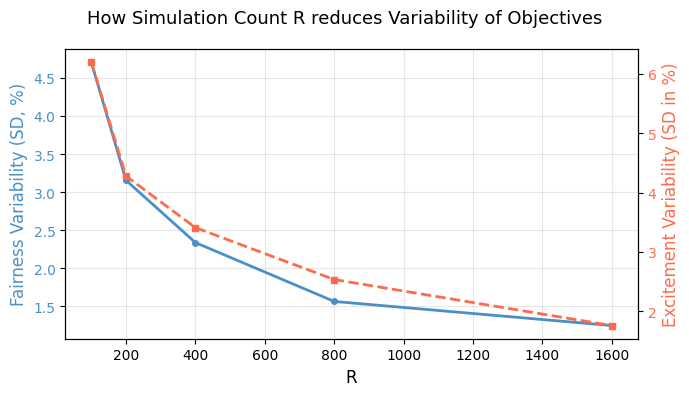


INTERPRETATION:
The variance values above represent how much the estimated metrics fluctuate
when running simulations with different seeds, for a fixed R.
As R increases, this variance should DECREASE, showing convergence to the true mean.
This is the Law of Large Numbers in action: larger R → more stable estimates.


In [41]:
import matplotlib.pyplot as plt
import pandas as pd
# Calculate convergence to mean: for each R, show how the estimated value converges
print("\n" + "="*80)
print("CONVERGENCE ANALYSIS: How variance decreases with increasing R")
print("="*80 + "\n")

convergence_stats = []

for num_rep in repetitions_list:
    rep_results = [r for r in results_storage if r['repetitions'] == num_rep]
    
    win_rates = [r['p4_win_rate'] for r in rep_results]
    trick_changes = [r['avg_trick_changes'] for r in rep_results]
    
    # The variance we calculated represents sampling variance
    # As R increases, this variance should decrease
    mean_win_rate = np.mean(win_rates)
    var_win_rate = np.var(win_rates)
    std_win_rate = np.std(win_rates)
    
    mean_tricks = np.mean(trick_changes)
    var_tricks = np.var(trick_changes)
    std_tricks = np.std(trick_changes)
    
    convergence_stats.append({
        'R': num_rep,
        'mean_win_rate': mean_win_rate,
        'var_win_rate': var_win_rate,
        'std_win_rate': std_win_rate,
        'mean_tricks': mean_tricks,
        'var_tricks': var_tricks,
        'std_tricks': std_tricks
    })
    
    print(f"R = {num_rep}:")
    print(f"{win_rates}")
    print(f"  P4 Win Rate (estimated from {len(rep_results)} different seeds):")
    print(f"    Mean estimate: {mean_win_rate:.4f} ({mean_win_rate:.2%})")
    print(f"    Sampling Variance: {var_win_rate:.6f}")
    print(f"    Sampling Std Dev: {std_win_rate:.6f}")
    print(f"  Average Trick Changes (estimated from {len(rep_results)} different seeds):")
    print(f"    Mean estimate: {mean_tricks:.4f}")
    print(f"    Sampling Variance: {var_tricks:.6f}")
    print(f"    Sampling Std Dev: {std_tricks:.6f}")
    print()

# Create convergence DataFrame
df_convergence = pd.DataFrame(convergence_stats)
print("\nConvergence Table (Variance should decrease as R increases):")
print(df_convergence[['R', 'mean_win_rate', 'var_win_rate', 'std_win_rate', 'mean_tricks', 'var_tricks', 'std_tricks']].to_string(index=False))

# Convert stds to percent for plotting
fairness_std_pct = 100 * df_convergence['std_win_rate']
excitement_std_pct = 100 * df_convergence['std_tricks'] / df_convergence['mean_tricks'].max()  # relative to max mean excitement

# Poster-friendly plot size (e.g., 7 x 4 inches, adjust as needed for your poster layout)
fig, ax1 = plt.subplots(1, 1, figsize=(7, 4))

# Plot 1: Fairness Variability (Std Dev) on left y-axis
color1 = palette['blue']
ax1.set_xlabel('R', fontsize=12)
ax1.set_ylabel('Fairness Variability (SD, %)', fontsize=12, color=color1)
ax1.plot(df_convergence['R'], fairness_std_pct, 'o-', linewidth=2, markersize=4, label='Fairness Variability', color=color1)  # smaller points
ax1.tick_params(axis='y', labelcolor=color1)
ax1.grid(True, alpha=0.3)

# Plot 2: Excitement Variability (Std Dev) on right y-axis
ax2 = ax1.twinx()
color2 = palette['coral']
ax2.set_ylabel('Excitement Variability (SD in %)', fontsize=12, color=color2)
ax2.plot(df_convergence['R'], excitement_std_pct, 's--', linewidth=2, markersize=4, label='Excitement Variability', color=color2)  # smaller points
ax2.tick_params(axis='y', labelcolor=color2)

fig.suptitle('How Simulation Count R reduces Variability of Objectives', fontsize=13)
fig.tight_layout()

plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("INTERPRETATION:")
print("="*80)
print("The variance values above represent how much the estimated metrics fluctuate")
print("when running simulations with different seeds, for a fixed R.")
print("As R increases, this variance should DECREASE, showing convergence to the true mean.")
print("This is the Law of Large Numbers in action: larger R → more stable estimates.")

## Pymoo connection

TopTrumpsBalancing provides a pymoo-compatible interface for TopTrumpsSimulation. Note that the objectives are already negated to result in a minimization problem!

In [11]:
import numpy as np
from pymoo.core.problem import ElementwiseProblem

class TopTrumpsBalancing(ElementwiseProblem):
    """TopTrumpsBalancing connects TopTrumpsSimulation with the pymoo interface ElementwiseProblem."""

    def __init__(self, sim_instance, n_simulations=100):
        self.sim = sim_instance
        self.n_simulations = n_simulations
        
        # KL variables: Number of cards (K) * Categories (L) 
        n_var = self.sim.K * self.sim.L
        
        super().__init__(n_var=n_var,
                         n_obj=2, # Objectives: Fairness (p4 win rate) and Excitement (# trick changes)
                         n_constr=0,
                         xl=1.0, # Lower bound for values
                         xu=10.0) # Upper bound for values

    def _evaluate(self, x, out, *args, **kwargs):
        # Update simulation with the current candidate deck
        self.sim.set_deck(x)
        
        win_rates = []
        trick_changes_list = []
        
        # Perform multiple simulations to get an average
        for _ in range(self.n_simulations):
            res = self.sim.simulate_game()
            win_rates.append(1 if res['p4_won'] else 0)
            trick_changes_list.append(res['trick_changes'])
        
        # Objectives (Minimization):
        # f1: -Average Win Rate of p4 (Fairness)
        # f2: -Average Trick Changes (Excitement)
        out["F"] = [
            -np.mean(win_rates), 
            -np.mean(trick_changes_list)
        ]

Set up simulation and problem instance:

Now it's your turn: Optimize `problem` using an approach of your choice and analyze the results. Please refer to the documentation of [pymoo](https://pymoo.org) for more details. A good starting point is: <https://pymoo.org/getting_started/part_2.html#Initialize-an-Algorithm>

In [24]:
my_sim_100 = TopTrumpsSimulation(num_cards=22, num_categories=4)
problem_100 = TopTrumpsBalancing(my_sim_100, n_simulations=100)
my_sim_1000 = TopTrumpsSimulation(num_cards=22, num_categories=4)
problem_1000 = TopTrumpsBalancing(my_sim_1000, n_simulations=1000)

In [30]:
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.operators.crossover.sbx import SBX
from pymoo.operators.mutation.pm import PM
from pymoo.operators.sampling.lhs import LHS
from pymoo.termination import get_termination
from pymoo.optimize import minimize
import random
import numpy as np

# Set seeds for reproducibility
np.random.seed(1)
random.seed(1)

algorithm = NSGA2(
    pop_size=100,  # Increased from 40
    n_offsprings=50,  # Increased from 10
    sampling=LHS(),  # Better initial distribution
    crossover=SBX(prob=0.9, eta=10),  # Lower eta for more exploration
    mutation=PM(eta=15, prob=1.0/problem_1000.n_var),  # More explorative mutation
    eliminate_duplicates=True
)

termination = get_termination("n_gen", 200)  # More generations

res_100 = minimize(problem_100,
               algorithm,
               termination,
               seed=1,
               save_history=True,
               verbose=True)

n_gen  |  n_eval  | n_nds  |      eps      |   indicator  
     1 |      100 |      2 |             - |             -
     2 |      150 |      2 |  0.000000E+00 |             f
     3 |      200 |      2 |  0.000000E+00 |             f
     4 |      250 |      2 |  0.000000E+00 |             f
     5 |      300 |      3 |  0.6097560976 |         ideal
     6 |      350 |      3 |  0.000000E+00 |             f
     7 |      400 |      3 |  0.000000E+00 |             f
     8 |      450 |      4 |  0.0810242305 |             f
     9 |      500 |      4 |  0.000000E+00 |             f
    10 |      550 |      3 |  0.1838335238 |             f
    11 |      600 |      3 |  0.000000E+00 |             f
    12 |      650 |      3 |  0.1086956522 |         ideal
    13 |      700 |      3 |  0.000000E+00 |             f
    14 |      750 |      3 |  0.000000E+00 |             f
    15 |      800 |      5 |  0.2323232323 |         ideal
    16 |      850 |      6 |  0.0438761645 |            

In [27]:
# Set seeds for reproducibility
np.random.seed(1)
random.seed(1)

algorithm = NSGA2(
    pop_size=100,  # Increased from 40
    n_offsprings=50,  # Increased from 10
    sampling=LHS(),  # Better initial distribution
    crossover=SBX(prob=0.9, eta=10),  # Lower eta for more exploration
    mutation=PM(eta=15, prob=1.0/problem_1000.n_var),  # More explorative mutation
    eliminate_duplicates=True
)

termination = get_termination("n_gen", 200)  # More generations

res_1000 = minimize(problem_1000,
               algorithm,
               termination,
               seed=1,
               save_history=True,
               verbose=True)

n_gen  |  n_eval  | n_nds  |      eps      |   indicator  
     1 |      100 |      2 |             - |             -
     2 |      150 |      3 |  0.1937448434 |             f
     2 |      150 |      3 |  0.1937448434 |             f
     3 |      200 |      5 |  0.4179104478 |         ideal
     3 |      200 |      5 |  0.4179104478 |         ideal
     4 |      250 |      5 |  0.000000E+00 |             f
     4 |      250 |      5 |  0.000000E+00 |             f
     5 |      300 |      5 |  0.000000E+00 |             f
     5 |      300 |      5 |  0.000000E+00 |             f
     6 |      350 |      5 |  0.000000E+00 |             f
     6 |      350 |      5 |  0.000000E+00 |             f
     7 |      400 |      5 |  0.2637362637 |         ideal
     7 |      400 |      5 |  0.2637362637 |         ideal
     8 |      450 |      6 |  0.2003338898 |         ideal
     8 |      450 |      6 |  0.2003338898 |         ideal
     9 |      500 |      6 |  0.1634078212 |         ide

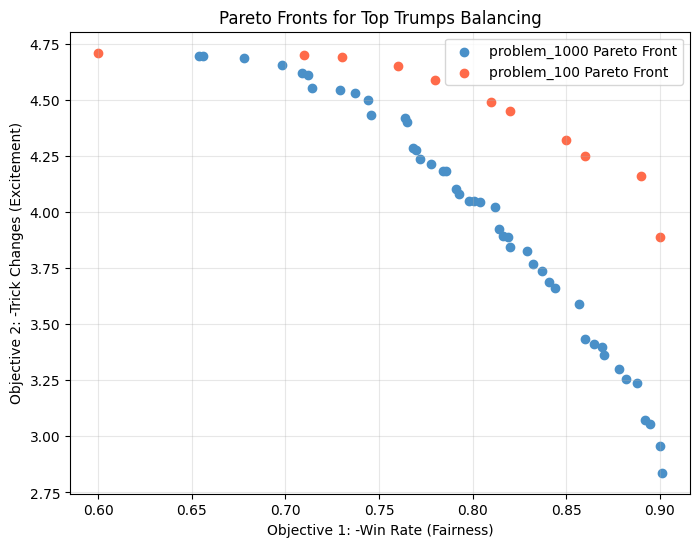

In [31]:
import matplotlib.pyplot as plt

# Visualize Pareto fronts for problem_100 and problem_1000 using the custom palette
fig, ax = plt.subplots(1, 1, figsize=(8, 6))

# Use palette colors for the two fronts
color_1000 = palette['blue']      # Blue for problem_1000
color_100 = palette['coral']      # Coral for problem_100

# For problem_1000
ax.scatter(-res_1000.F[:, 0], -res_1000.F[:, 1], c=color_1000, label='problem_1000 Pareto Front', alpha=1)

# For problem_100
ax.scatter(-res_100.F[:, 0], -res_100.F[:, 1], c=color_100, label='problem_100 Pareto Front', alpha=1)

ax.set_xlabel('Objective 1: -Win Rate (Fairness)')
ax.set_ylabel('Objective 2: -Trick Changes (Excitement)')
ax.set_title('Pareto Fronts for Top Trumps Balancing')
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

In [32]:
# Verify Pareto front deck objective values with R=10000 using direct simulation (no Problem class)
verified_F_100 = []
verified_F_1000 = []

# For problem_100
sim_100_verify = TopTrumpsSimulation(num_cards=22, num_categories=4)
for deck in res_100.X:
    sim_100_verify.set_deck(deck)
    win_rates = []
    trick_changes_list = []
    for _ in range(10000):
        res_sim = sim_100_verify.simulate_game()
        win_rates.append(1 if res_sim['p4_won'] else 0)
        trick_changes_list.append(res_sim['trick_changes'])
    verified_F_100.append([
        -np.mean(win_rates),
        -np.mean(trick_changes_list)
    ])
print("done with 100")
# For problem_1000
sim_1000_verify = TopTrumpsSimulation(num_cards=22, num_categories=4)
for deck in res_1000.X:
    sim_1000_verify.set_deck(deck)
    win_rates = []
    trick_changes_list = []
    for _ in range(10000):
        res_sim = sim_1000_verify.simulate_game()
        win_rates.append(1 if res_sim['p4_won'] else 0)
        trick_changes_list.append(res_sim['trick_changes'])
    verified_F_1000.append([
        -np.mean(win_rates),
        -np.mean(trick_changes_list)
    ])

# Convert to numpy arrays for consistency with res.F
verified_F_100 = np.array(verified_F_100)
verified_F_1000 = np.array(verified_F_1000)

print('Verified objectives for problem_100 (R=10000):', verified_F_100)
print('Verified objectives for problem_1000 (R=10000):', verified_F_1000)

done with 100
Verified objectives for problem_100 (R=10000): [[-0.715  -4.1674]
 [-0.7428 -3.9988]
 [-0.6717 -4.2713]
 [-0.7746 -3.7736]
 [-0.7795 -3.9021]
 [-0.8025 -3.7689]
 [-0.7227 -4.1618]
 [-0.6932 -4.3289]
 [-0.6967 -4.2731]
 [-0.6949 -4.2398]
 [-0.7111 -4.2731]]
Verified objectives for problem_1000 (R=10000): [[-0.7677 -4.0297]
 [-0.7938 -3.747 ]
 [-0.7999 -3.7853]
 [-0.8514 -3.317 ]
 [-0.8541 -3.2287]
 [-0.777  -3.9443]
 [-0.8745 -2.7775]
 [-0.801  -3.8207]
 [-0.841  -3.3452]
 [-0.7696 -4.0062]
 [-0.8049 -3.7555]
 [-0.6955 -4.4994]
 [-0.7436 -4.1767]
 [-0.8325 -3.4573]
 [-0.7948 -3.8426]
 [-0.7087 -4.4197]
 [-0.774  -3.9557]
 [-0.8744 -2.9395]
 [-0.7757 -3.9773]
 [-0.8126 -3.7325]
 [-0.7015 -4.4926]
 [-0.7678 -4.0259]
 [-0.7053 -4.4614]
 [-0.6731 -4.5803]
 [-0.7371 -4.2079]
 [-0.6861 -4.5082]
 [-0.7952 -3.6938]
 [-0.7137 -4.3865]
 [-0.7602 -4.1215]
 [-0.7273 -4.3481]
 [-0.8236 -3.6032]
 [-0.8341 -3.4293]
 [-0.8662 -3.0132]
 [-0.8613 -3.1674]
 [-0.8171 -3.6046]
 [-0.6951 -4.459

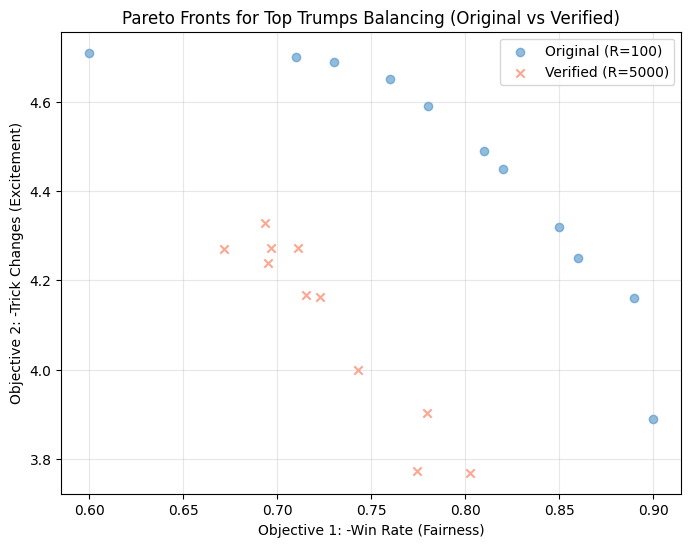

In [33]:
# Plot original vs verified objectives for problem_100 using the color palette
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 1, figsize=(8, 6))

# Original objectives from optimization
ax.scatter(-res_100.F[:, 0], -res_100.F[:, 1], c=palette['blue'], label='Original (R=100)', alpha=0.6)

# Verified objectives with R=5000
ax.scatter(-verified_F_100[:, 0], -verified_F_100[:, 1], c=palette['coral'], label='Verified (R=5000)', alpha=0.6, marker='x')

ax.set_xlabel('Objective 1: -Win Rate (Fairness)')
ax.set_ylabel('Objective 2: -Trick Changes (Excitement)')
ax.set_title('Pareto Fronts for Top Trumps Balancing (Original vs Verified)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

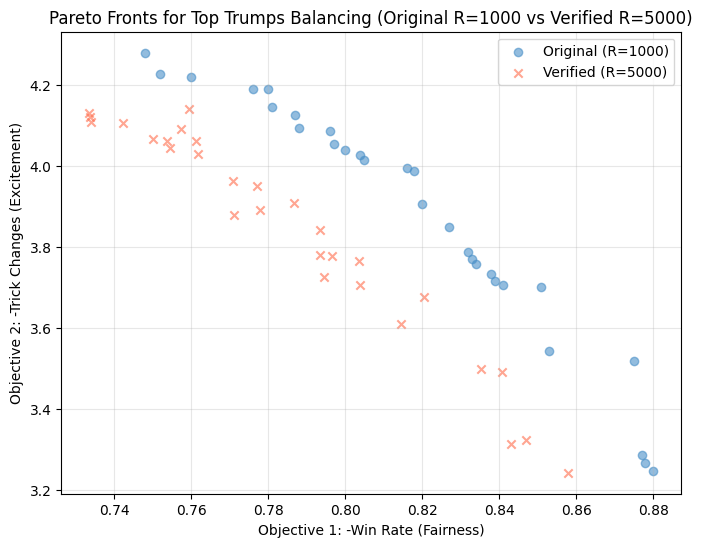

In [19]:
# Plot original vs verified objectives for problem_1000 using the color palette
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 1, figsize=(8, 6))

# Original objectives from optimization
ax.scatter(-res_1000.F[:, 0], -res_1000.F[:, 1], c=palette['blue'], label='Original (R=1000)', alpha=0.6)

# Verified objectives with R=5000
ax.scatter(-verified_F_1000[:, 0], -verified_F_1000[:, 1], c=palette['coral'], label='Verified (R=5000)', alpha=0.6, marker='x')

ax.set_xlabel('Objective 1: -Win Rate (Fairness)')
ax.set_ylabel('Objective 2: -Trick Changes (Excitement)')
ax.set_title('Pareto Fronts for Top Trumps Balancing (Original R=1000 vs Verified R=5000)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

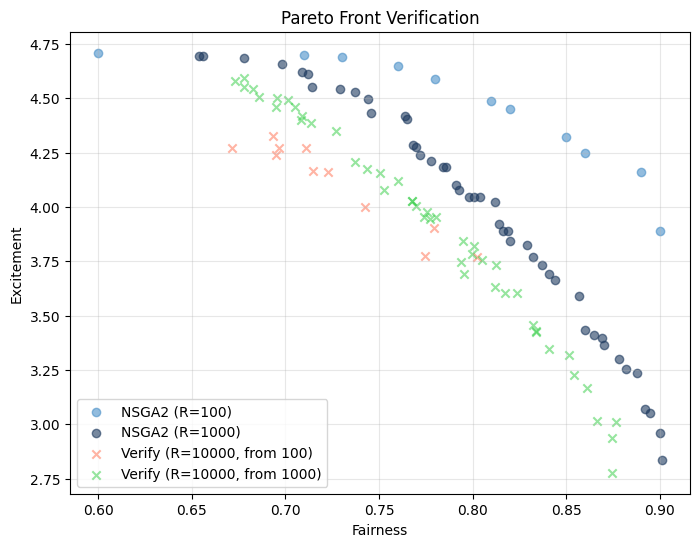

In [40]:
# Plot all Pareto fronts (original and verified for both R=100 and R=1000) together using the updated color palette
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 1, figsize=(8, 6))

# Original objectives from optimization
ax.scatter(-res_100.F[:, 0], -res_100.F[:, 1], c=palette['blue'], label='NSGA2 (R=100)', alpha=0.6)
ax.scatter(-res_1000.F[:, 0], -res_1000.F[:, 1], c=palette['navy'], label='NSGA2 (R=1000)', alpha=0.6)

# Verified objectives
ax.scatter(-verified_F_100[:, 0], -verified_F_100[:, 1], c=palette['coral'], label='Verify (R=10000, from 100)', alpha=0.5, marker='x')
ax.scatter(-verified_F_1000[:, 0], -verified_F_1000[:, 1], c=palette['green'], label='Verify (R=10000, from 1000)', alpha=0.5, marker='x')

ax.set_xlabel('Fairness')
ax.set_ylabel('Excitement')
ax.set_title('Pareto Front Verification')
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

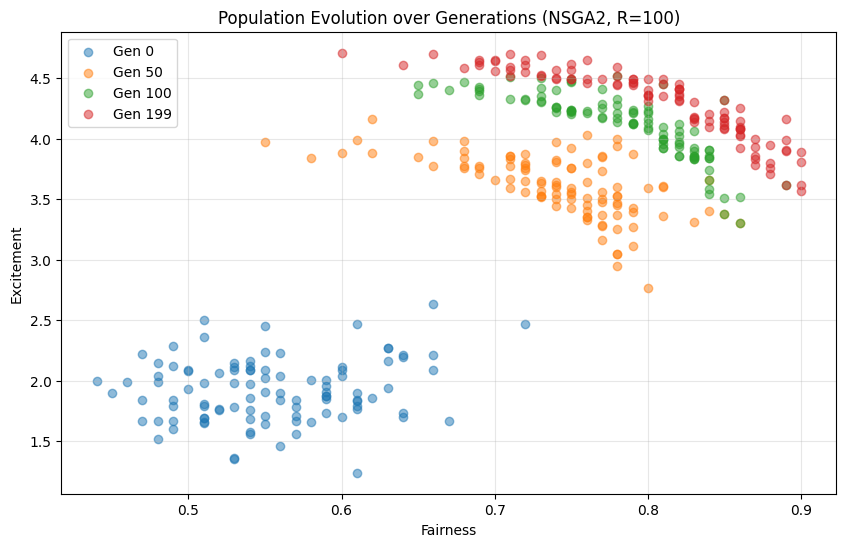

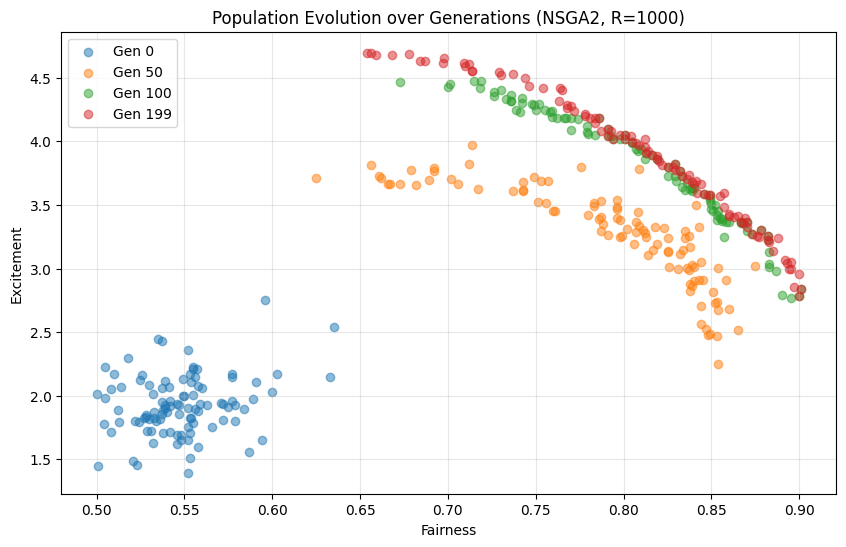

In [42]:
import matplotlib.pyplot as plt

def plot_history_fronts(history, palette, generations=[0, 10, 50, 100, 199], R=100, algo_name="NSGA2"):
    plt.figure(figsize=(10, 6))
    for gen in generations:
        if gen < len(history):
            F = history[gen].pop.get("F")
            plt.scatter(-F[:, 0], -F[:, 1], label=f"Gen {gen}", alpha=0.5)
    plt.xlabel("Fairness")
    plt.ylabel("Excitement")
    plt.title(f"Population Evolution over Generations ({algo_name}, R={R})")
    plt.legend(loc="upper left")
    plt.grid(True, alpha=0.3)
    plt.show()

# For problem_100
plot_history_fronts(res_100.history, palette, generations=[0, 50, 100, 199], R=100, algo_name="NSGA2")

# For problem_1000
plot_history_fronts(res_1000.history, palette, generations=[0, 50, 100, 199], R=1000, algo_name="NSGA2")
